# Card 0 — Measure the data before modelling anything

**The problem.** We want to predict which credit-card customers will default next month. Before any model, we measure the data — your own Block 0 rule.

**The number.** The base rate of default, and how it varies by segment (with a confidence interval).

**Pairs with.** Module 1: base rates, mean vs. median, heavy tails, confidence intervals for a proportion.

**How to work.** Run each cell (Shift+Enter), read the output, then read the comment under it. At the end, answer the five questions in `docs/NOTES.md` in your own words.

---

## The data

30,000 credit-card customers of a Taiwanese bank (2005). Amounts are in New Taiwan dollars (NT$; ~30 NT$ = 1 €).

| Column | Meaning |
|---|---|
| `LIMIT_BAL` | credit limit |
| `SEX` | 1 = male, 2 = female |
| `EDUCATION` | 1 = graduate school, 2 = university, 3 = high school, 4 = other (0, 5, 6 = undocumented) |
| `MARRIAGE` | 1 = married, 2 = single, 3 = other (0 = undocumented) |
| `AGE` | years |
| `PAY_0` … `PAY_6` | repayment status in Sept … April 2005: −2 = no consumption, −1 = paid in full, 0 = revolving credit, 1 = one month late, 2 = two months late … 9 = nine+ months late. **`PAY_0` is the most recent month.** |
| `BILL_AMT1` … `BILL_AMT6` | bill statement amount, Sept … April |
| `PAY_AMT1` … `PAY_AMT6` | amount actually paid, Sept … April |
| `default` | **target**: 1 = defaulted on the next payment, 0 = did not |


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.width", 140)
df = pd.read_csv("../lab/data/credit_default_uci.csv")
print(df.shape)
df.head()

Matplotlib is building the font cache; this may take a moment.


(30000, 24)


,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default
0,20000,2,2,1,24,2,2,-1,-1,-2,...,0,0,0,0,689,0,0,0,0,1
1,120000,2,2,2,26,-1,2,0,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,2,2,2,34,0,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,50000,2,2,1,37,0,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,50000,1,2,1,57,-1,0,-1,0,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


## 1 · The base rate — the most important number in the problem

How many customers default? Everything downstream — what "accuracy" means, how many alerts are false, how much a model has to beat — depends on this.

In [2]:
n = len(df)
defaults = df["default"].sum()
base_rate = defaults / n
print(f"customers: {n:,}   defaults: {defaults:,}   base rate: {base_rate:.1%}")

# Module 1: a 95% confidence interval for a proportion = p ± 1.96 * sqrt(p(1-p)/n)
se = np.sqrt(base_rate * (1 - base_rate) / n)
print(f"95% CI for the base rate: {base_rate - 1.96*se:.2%} – {base_rate + 1.96*se:.2%}   (standard error {se:.3%})")

# The accuracy trap: a 'model' that predicts NOBODY defaults
print(f"\nAccuracy of the model that always says 'no default': {1 - base_rate:.1%}")

customers: 30,000   defaults: 6,636   base rate: 22.1%
95% CI for the base rate: 21.65% – 22.59%   (standard error 0.240%)

Accuracy of the model that always says 'no default': 77.9%


> **Read this.** 22 % default. So a model that never predicts default is already 78 % "accurate" — and useless. This is why accuracy is the wrong metric for this problem (Card 1 shows what to use instead). Note also how narrow the confidence interval is with 30,000 customers: ±0.5 pp. Remember that for later, when we look at small segments.

## 2 · Mean vs. median — money is heavy-tailed

Module 1, section 3: transaction amounts and balances are not normal. Let's see it.

In [3]:
cols = ["LIMIT_BAL", "BILL_AMT1", "PAY_AMT1", "AGE"]
summary = pd.DataFrame({
    "mean": df[cols].mean().round(0),
    "median": df[cols].median().round(0),
    "std": df[cols].std().round(0),
    "p5": df[cols].quantile(0.05).round(0),
    "p95": df[cols].quantile(0.95).round(0),
    "max": df[cols].max(),
})
summary

,mean,median,std,p5,p95,max
LIMIT_BAL,167484.0,140000.0,129748.0,20000.0,430000.0,1000000
BILL_AMT1,51223.0,22382.0,73636.0,0.0,201203.0,964511
PAY_AMT1,5664.0,2100.0,16563.0,0.0,18428.0,873552
AGE,35.0,34.0,9.0,23.0,53.0,79


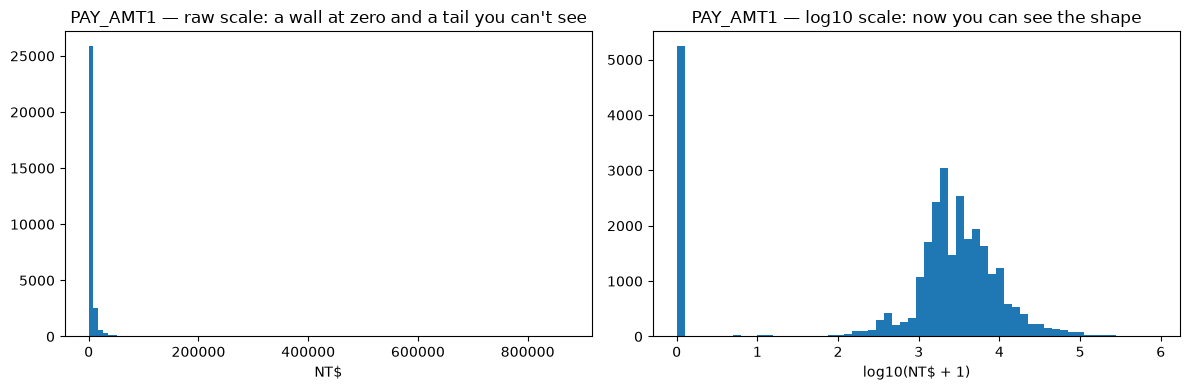

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df["PAY_AMT1"], bins=100)
axes[0].set_title("PAY_AMT1 — raw scale: a wall at zero and a tail you can't see")
axes[0].set_xlabel("NT$")
axes[1].hist(np.log10(df["PAY_AMT1"] + 1), bins=60)
axes[1].set_title("PAY_AMT1 — log10 scale: now you can see the shape")
axes[1].set_xlabel("log10(NT$ + 1)")
plt.tight_layout(); plt.show()

> **Read this.** For `PAY_AMT1` the mean is well above the median: a few customers paying huge amounts drag the average up. `AGE`, by contrast, has mean ≈ median — it's roughly symmetric. Rule from Module 1: for money, quote the **median and percentiles**; take the **log** before modelling. The right-hand plot is the same data — only the axis changed.

## 3 · Data quality — values the dictionary doesn't explain

Real data always has these. A model will happily learn from garbage; you have to look first.

In [5]:
print("EDUCATION values:", df["EDUCATION"].value_counts().sort_index().to_dict())
print("MARRIAGE values: ", df["MARRIAGE"].value_counts().sort_index().to_dict())
print("PAY_0 values:    ", df["PAY_0"].value_counts().sort_index().to_dict())
print()
print(f"rows with a negative bill (BILL_AMT1 < 0): {(df['BILL_AMT1'] < 0).sum():,}  -> the bank owes the customer (overpayment / refund). Legit, not an error.")
print(f"rows with EDUCATION in (0,5,6):           {df['EDUCATION'].isin([0,5,6]).sum():,}  -> undocumented codes")
print(f"rows with MARRIAGE = 0:                   {(df['MARRIAGE'] == 0).sum():,}  -> undocumented code")
print(f"missing values anywhere:                  {df.isna().sum().sum()}")

EDUCATION values: {0: 14, 1: 10585, 2: 14030, 3: 4917, 4: 123, 5: 280, 6: 51}
MARRIAGE values:  {0: 54, 1: 13659, 2: 15964, 3: 323}
PAY_0 values:     {-2: 2759, -1: 5686, 0: 14737, 1: 3688, 2: 2667, 3: 322, 4: 76, 5: 26, 6: 11, 7: 9, 8: 19}

rows with a negative bill (BILL_AMT1 < 0): 590  -> the bank owes the customer (overpayment / refund). Legit, not an error.
rows with EDUCATION in (0,5,6):           345  -> undocumented codes
rows with MARRIAGE = 0:                   54  -> undocumented code
missing values anywhere:                  0


> **Read this.** No missing values — but "no missing values" is not "clean": there are undocumented codes (EDUCATION 0/5/6, MARRIAGE 0) and `PAY_0` has values −2 and 0 that the original paper doesn't define well. Decision for later cards: fold 0/5/6 into "other" (4), fold MARRIAGE 0 into "other" (3). Negative bills are real. **Write down every such decision** — in an interview, "what did you do with the undocumented codes?" is a standard question.

## 4 · Where is the signal? Default rate by segment

This is the heart of Block 0: which variables move the default rate, and by how much. For each segment we show the rate, the count, and the 95 % confidence interval — so you can tell a real difference from noise.

In [6]:
def rate_by(col, bins=None, labels=None):
    s = df[col] if bins is None else pd.cut(df[col], bins=bins, labels=labels, include_lowest=True)
    g = df.groupby(s, observed=True)["default"].agg(["mean", "count"]).rename(columns={"mean": "default_rate", "count": "n"})
    g["ci95_pm"] = 1.96 * np.sqrt(g["default_rate"] * (1 - g["default_rate"]) / g["n"])
    return g

def show(g, title):
    out = g.copy()
    out["default_rate"] = (out["default_rate"]*100).round(1)
    out["ci95_pm"] = (out["ci95_pm"]*100).round(1)
    out.columns = ["default rate %", "n", "± 95% CI (pp)"]
    print(f"\n{title}"); print(out.to_string())

show(rate_by("PAY_0"), "By PAY_0 — repayment status last month (the strongest single signal)")
show(rate_by("LIMIT_BAL", bins=[0, 50e3, 100e3, 200e3, 300e3, 1e7], labels=["≤50k", "50–100k", "100–200k", "200–300k", ">300k"]), "By credit limit")
show(rate_by("AGE", bins=[20, 30, 40, 50, 60, 80], labels=["21–30", "31–40", "41–50", "51–60", "61+"]), "By age")
show(rate_by("SEX"), "By sex (1 = male, 2 = female)")
show(rate_by("EDUCATION"), "By education")


By PAY_0 — repayment status last month (the strongest single signal)
       default rate %      n  ± 95% CI (pp)
PAY_0                                      
-2               13.2   2759            1.3
-1               16.8   5686            1.0
 0               12.8  14737            0.5
 1               33.9   3688            1.5
 2               69.1   2667            1.8
 3               75.8    322            4.7
 4               68.4     76           10.5
 5               50.0     26           19.2
 6               54.5     11           29.4
 7               77.8      9           27.2
 8               57.9     19           22.2

By credit limit
           default rate %     n  ± 95% CI (pp)
LIMIT_BAL                                     
≤50k                 31.8  7676            1.0
50–100k              25.8  4822            1.2
100–200k             19.5  7880            0.9
200–300k             16.1  5059            1.0
>300k                13.3  4563            1.0

By age
    

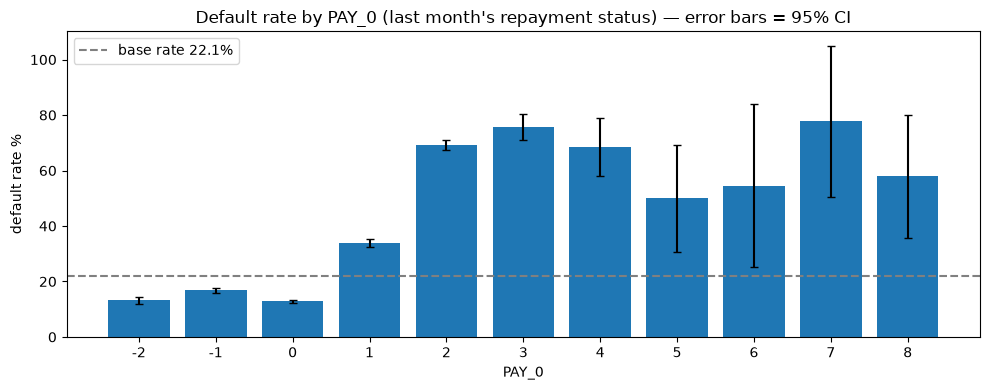

In [7]:
g = rate_by("PAY_0")
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(g.index.astype(str), g["default_rate"]*100, yerr=g["ci95_pm"]*100, capsize=3)
ax.axhline(base_rate*100, color="grey", linestyle="--", label=f"base rate {base_rate:.1%}")
ax.set_title("Default rate by PAY_0 (last month's repayment status) — error bars = 95% CI")
ax.set_xlabel("PAY_0"); ax.set_ylabel("default rate %"); ax.legend()
plt.tight_layout(); plt.show()

> **Read this.** Look at `PAY_0`: customers who paid on time or revolve (−1, 0) default around 13–17 %; **one month late jumps to ~34 %, two months late to ~69 %**. That single variable separates the population more than everything else combined — which is plausible: the best predictor of not paying next month is not paying this month. Now look at the error bars on the rare values (PAY_0 = 5, 6, 7, 8): tiny counts, huge intervals — those rates mean almost nothing. Same for the 61+ age bucket. **Module 1 in one picture: a percentage without its n and its CI is not a number.**

## 5 · Correlation with the target — a first ranking of features

Point-biserial correlation (a normal correlation between a 0/1 target and a numeric feature). Crude, linear only — but a fine first look.

In [8]:
corr = df.drop(columns=["default"]).corrwith(df["default"]).sort_values(key=abs, ascending=False)
corr.round(3).head(12)

PAY_0        0.325
PAY_2        0.264
PAY_3        0.235
PAY_4        0.217
PAY_5        0.204
PAY_6        0.187
LIMIT_BAL   -0.154
PAY_AMT1    -0.073
PAY_AMT2    -0.059
PAY_AMT4    -0.057
PAY_AMT3    -0.056
PAY_AMT5    -0.055
dtype: float64

> **Read this.** The `PAY_*` columns dominate; `LIMIT_BAL` is negative (higher limit → lower default: the bank already gave more credit to safer people — that's a **selection effect** baked into the data, remember Module 1 §4 on survivorship). Bill amounts are almost uncorrelated on their own. Correlation ≈ 0 does *not* mean useless: a model can combine bills and payments into something informative (e.g. "paid / billed" ratio). Card 3 will show whether it does.

## 6 · A taste of Card 1 — the hand-made rule

Before any model: the rule a credit analyst would write on a napkin. *"If the customer was late last month, they'll default."* Let's count, by hand, how good that rule is.

In [9]:
rule = (df["PAY_0"] >= 1).astype(int)     # predict default if at least one month late
y = df["default"]

tp = int(((rule == 1) & (y == 1)).sum())   # predicted default, did default
fp = int(((rule == 1) & (y == 0)).sum())   # predicted default, did NOT default (false alarm)
fn = int(((rule == 0) & (y == 1)).sum())   # predicted fine, did default (missed)
tn = int(((rule == 0) & (y == 0)).sum())

precision = tp / (tp + fp)    # of those we flagged, how many really defaulted
recall    = tp / (tp + fn)    # of real defaulters, how many we caught
accuracy  = (tp + tn) / n

print(f"flagged: {tp+fp:,} customers ({(tp+fp)/n:.1%} of all)")
print(f"TP {tp:,}  FP {fp:,}  FN {fn:,}  TN {tn:,}")
print(f"precision {precision:.1%}   recall {recall:.1%}   accuracy {accuracy:.1%}   (base rate {base_rate:.1%})")

flagged: 6,818 customers (22.7% of all)
TP 3,429  FP 3,389  FN 3,207  TN 19,975
precision 50.3%   recall 51.7%   accuracy 78.0%   (base rate 22.1%)


> **Read this.** The napkin rule flags ~23 % of customers; about half of those really default (precision ≈ 50 %, vs. a base rate of 22 % — so the rule more than doubles our odds), and it catches ~52 % of all defaulters (recall). Accuracy barely moved from the "never default" model's 78 %. **This is the baseline every model in Card 1 has to beat** — and it's the same P(flag | default) vs. P(default | flag) distinction from Module 1's Bayes example.

---

## Your five questions → `docs/NOTES.md`

Answer in your own words, in English, as if a data scientist at Revolut had just asked you.

1. What is the base rate here, and why does it make "accuracy" a misleading metric?
2. Credit limit and payment amounts: which statistic would you put on a dashboard, mean or median, and why?
3. Which single variable carries the most signal, and why is that plausible from a business point of view?
4. Name two data-quality decisions you'd have to make before training, and what you'd do.
5. The 61+ age bucket shows a certain default rate. Would you tell the business "older customers default more/less"? Use the n and the CI in your answer.
